# **PHẦN 4: HUẤN LUYỆN MÔ HÌNH**
## **1. Định nghĩa vấn đề**
+ **Mô tả**:
   - Phát hiện và phân loại mã độc trên các thiết bị di động Android bằng tập dữ liệu Android Malware Detection.
   - Huấn luyện và đánh giá hiệu suất học của các mô hình.
+ **Mục tiêu**:
   - Huấn luyện các mô hình và đánh giá khả năng phân loại trên tập validation bằng nhiều tiêu chí đánh giá.
   - Huấn luyện các mô hình tốt nhất với tham số tối ưu và xuất ra file mô hình này.

## **2. Chuẩn bị vấn đề**

### 2.1. Import các thư viện cần thiết

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import math
import itertools

from imblearn.over_sampling import SMOTENC

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import learning_curve
from xgboost import plot_importance
import lightgbm as lgb

from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, auc, roc_curve
from sklearn.preprocessing import label_binarize

import time
import joblib

RANDOM_STATE = 42

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

### 2.2. Lấy tập dữ liệu đã xử lý

In [2]:
x_train = pd.read_parquet("../data_processed/x_train.parquet")
x_train.head()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
341993,-1.756805,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,2.341243,-1.924641,0.000000,0.000000,0.000000,0.0,-0.279107,-0.220216,0.0,0.0,0.0,1.0,0.0,0,0.000000,0.000000,0.0,0.000000,0.0,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,5.000000e-01,-0.866025,0.848644,0.528964,0,1,0,0,0,0,0,1,0,1
300839,0.866255,0.261860,0.000000,0.000000,0.0,-0.601360,0.0,-0.527324,-0.573250,1.000553,1.218707,0.000000,0.000000,0.0,0.325849,-0.214466,0.0,0.0,0.0,1.0,1.0,0,0.000000,11.407432,0.0,17.908537,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,5.000000e-01,0.866025,0.201299,0.979530,0,1,0,0,0,0,0,1,0,0
242949,0.454056,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.517768,0.748422,0.000000,0.000000,0.000000,0.0,0.044619,-0.220216,0.0,0.0,0.0,1.0,1.0,0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-8.660254e-01,-0.500000,0.998717,-0.050649,0,1,0,0,0,0,0,1,0,1
130533,0.210425,1.182658,0.409325,0.424611,0.0,0.728207,0.0,0.518443,0.082914,-0.193984,0.862406,1.062626,1.049584,0.0,0.904329,0.412438,0.0,0.0,1.0,0.0,0.0,0,0.822864,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-5.000000e-01,0.866025,0.790776,-0.612106,0,1,0,0,0,0,1,0,0,0
287524,-0.650190,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,0.712169,-0.586678,0.000000,0.000000,0.000000,0.0,0.044619,-0.220216,0.0,0.0,0.0,1.0,0.0,0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1.224647e-16,-1.000000,0.937752,0.347305,0,1,0,0,1,0,0,0,0,1


In [3]:
x_val = pd.read_parquet("../data_processed/x_val.parquet")
x_val.head()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
108563,0.308921,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.450671,0.572945,0.000000,0.000000,0.000000,0.0,-0.279107,-0.220216,0.0,0.0,0.0,1.0,1.0,0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,1,1,0,1,0,0,0,1,1,1,0,0,1,1,1,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.500000,-0.866025,0.848644,0.528964,0,1,0,0,0,0,1,0,0,1
339692,0.639939,0.261860,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.535380,0.726925,1.131617,0.000000,0.000000,0.0,0.199214,-0.201096,0.0,0.0,1.0,0.0,0.0,0,1.636899,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,0,1,1,1,0,1,0,0,0,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,-0.866025,0.500000,0.897805,-0.440394,0,1,0,0,0,0,0,1,0,0
145288,-0.146969,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,0.103439,-0.133614,0.841605,0.000000,0.000000,0.0,0.044619,0.335725,0.0,0.0,0.0,1.0,1.0,0,1.011778,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,1,1,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.866025,-0.500000,0.724793,0.688967,0,1,0,0,0,0,1,0,0,0
74532,0.866925,0.261860,-0.570892,-0.592211,0.0,0.031000,0.0,-0.527482,-0.569108,0.936883,1.208750,1.435116,1.681092,0.0,0.126160,-0.208849,0.0,0.0,0.0,1.0,0.0,0,1.136141,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,1,1,0,0,1,1,1,1,1,1,0,1,0,1,1,0,0,1,0,1,1,1,0,1,1,0,1,0,0,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,-0.866025,-0.500000,0.998717,-0.050649,0,1,0,0,0,1,0,0,0,0
87030,0.755895,1.929947,0.804863,0.652002,0.0,0.728207,0.0,0.188997,-0.343570,0.245678,1.072755,1.386679,1.326063,0.0,1.573624,-0.024373,0.0,0.0,1.0,0.0,0.0,1,1.128043,14.956261,0.0,17.216063,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,0,0,1,1,1,0,1,1,0,0,0,1,1,0,0,1,0,1,1,1,1,0,1,0,0,1,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.866025,0.500000,0.394356,0.918958,0,1,0,0,0,0,1,0,0,0


In [5]:
y_train = pd.read_parquet("../data_processed/y_train.parquet")
y_train.head()

,Label
341993,3
300839,2
242949,1
130533,0
287524,2


In [6]:
y_val = pd.read_parquet("../data_processed/y_val.parquet")
y_val.head()

,Label
108563,0
339692,3
145288,0
74532,0
87030,0


In [8]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()

## **3. Thực hiện vấn đề**

### 3.1. Thực hiện Oversampling giá trị thiểu số bằng SMOTENC.
Do lớp 2, 3 chiếm tỷ lệ ít, cần oversample để tránh mô hình thiên vị các lớp chiếm tỷ lệ đa số (0, 1) gây giảm khả năng dự đoán đúng trên lớp 2, 3.

In [ ]:
strategy = {
    2: 80000, 
    3: 50000
}

cat_indices = [i for i, col in enumerate(x_train.columns) if x_train[col].nunique() <= 3]
spn = SMOTENC(categorical_features=cat_indices, sampling_strategy=strategy, random_state=RANDOM_STATE)

x_train_res, y_train_res = spn.fit_resample(x_train, y_train)

### 3.2. Chọn các mô hình để huấn luyện
Các mô hình được chọn để huấn luyện bao gồm K-Nearest Neighbors, Naive Bayes, Logistic Regression, Linear Regression, Linear SVM, Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, DecisionTree, Kernel SVM. Các mô hình được gắn thêm trọng số"balanced" để bảo đảm mô hình không thiên vị các lớp đa số.

In [10]:

models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, 
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE,
                                              n_jobs=-1),
    "Linear SVM": LinearSVC(dual=False, class_weight='balanced', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight='balanced', 
                                            n_jobs=-1, 
                                            max_depth=20,
                                            random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', 
                                        n_jobs=-1, 
                                        max_depth=20,
                                        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric=["mlogloss", "merror"],
                             n_estimators=100,
                             max_depth=20,
                             random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(class_weight='balanced', 
                               n_estimators=1500,
                               max_depth=20,
                               learning_rate=0.1,
                               n_jobs=-1, 
                               random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', 
                                   verbose=False, 
                                   iterations=1500,
                                   learning_rate=0.1,
                                   depth=6,
                                   random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, 
        class_weight='balanced', 
        random_state=RANDOM_STATE
    ),
    "Kernel SVM": SVC(kernel='rbf', C=20.0, class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)

### 3.3. Thực hiện huấn luyện mô hình
Các mô hình được huấn luyện và đánh giá trên tập validation với các tham số F1 score và Accuracy để đánh giá sơ lược khả năng học trên tập dữ liệu train.

In [11]:
model_performance = []
training_logs = {}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    if name in ["XGBoost", "LightGBM", "CatBoost"]:
        if name == "XGBoost":
            model.fit(x_train_res, y_train_res,
                      eval_set=[(x_train_res, y_train_res), (x_val, y_val)],
                      verbose=False)
            training_logs[name] = model.evals_result()
            
        elif name == "LightGBM":
            import lightgbm as lgb
            
            model.fit(x_train_res, y_train_res,
                      eval_set=[(x_train_res, y_train_res), (x_val, y_val)],
                      eval_metric=['multi_logloss', 'multi_error'],
                      callbacks=[lgb.log_evaluation(period=0)])
            training_logs[name] = model.evals_result_
            
        elif name == "CatBoost":
            model.fit(x_train_res, y_train_res,
                      eval_set=(x_val, y_val),
                      verbose=False,
                      early_stopping_rounds=10)
            training_logs[name] = model.get_evals_result()
    else:
        model.fit(x_train_res, y_train_res)
    
    training_time = time.time() - start_time

    y_pred = model.predict(x_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    
    model_performance.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1-Score": f1,
        "Time (s)": training_time
    })
    
    print(f"Completed {name} in {training_time:.2f}s | F1: {f1:.4f} | Acc: {acc:.4f}\n")


Training K-Nearest Neighbors...
Completed K-Nearest Neighbors in 0.22s | F1: 0.7729 | Acc: 0.7970

Training Naive Bayes...
Completed Naive Bayes in 0.65s | F1: 0.4479 | Acc: 0.5438

Training Logistic Regression...
Completed Logistic Regression in 133.00s | F1: 0.6471 | Acc: 0.6718

Training Linear SVM...
Completed Linear SVM in 157.99s | F1: 0.6300 | Acc: 0.6644

Training Random Forest...
Completed Random Forest in 13.83s | F1: 0.8778 | Acc: 0.8900

Training Extra Trees...
Completed Extra Trees in 16.71s | F1: 0.8803 | Acc: 0.8936

Training XGBoost...
Completed XGBoost in 26.72s | F1: 0.8965 | Acc: 0.9023

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6546
[LightGBM] [Info] Number 

d:\Installs\Anaconda\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Completed Kernel SVM in 82.15s | F1: 0.3754 | Acc: 0.4878



**Nhận xét:** 
- Các mô hình K-Nearest Neighbors, Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, Decision Tree có F1-Score và Accuracy cao nhất.
- Các mô hình Logistic Regression và Linear SVM có F1-Score và Accuracy trung bình.
- Các mô hình Naive Bayes và Kernel SVM có F1-Score và Accuracy thấp nhất.

### 3.4. Đánh giá khả năng hội tụ của các mô hình

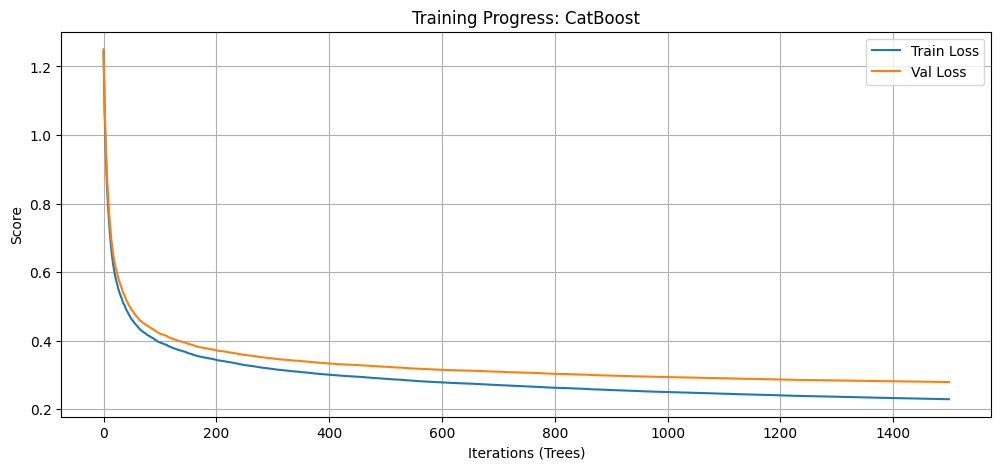

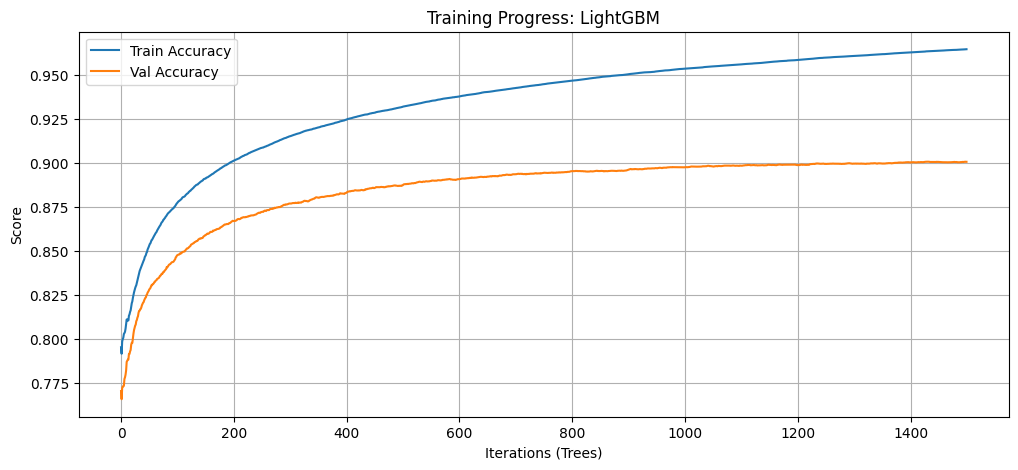

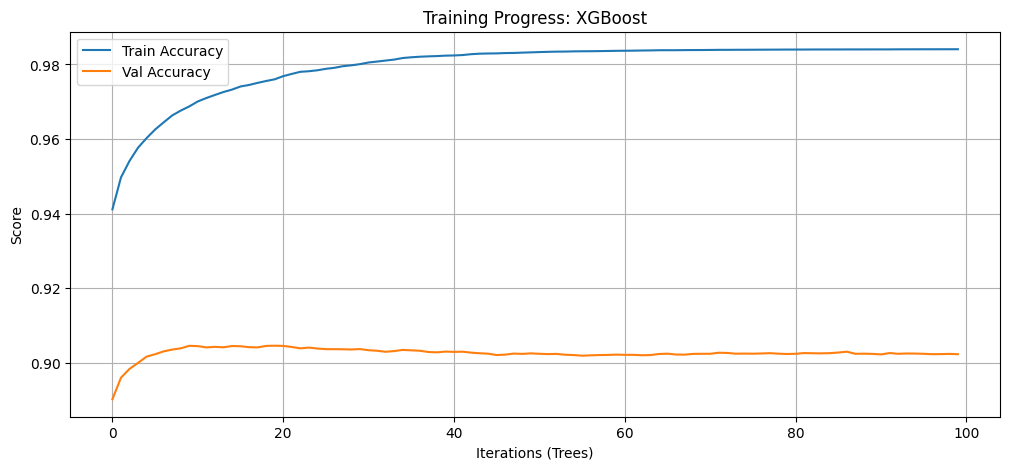

In [12]:
def plot_booster_logs(logs, model_name):
    plt.figure(figsize=(12, 5))
    
    if model_name == "XGBoost":
        if 'merror' in logs[model_name]['validation_0']:
            train_acc = [1 - x for x in logs[model_name]['validation_0']['merror']]
            val_acc = [1 - x for x in logs[model_name]['validation_1']['merror']]
            plt.plot(train_acc, label='Train Accuracy')
            plt.plot(val_acc, label='Val Accuracy')
        else:
            plt.plot(logs[model_name]['validation_0']['mlogloss'], label='Train Logloss')
            plt.plot(logs[model_name]['validation_1']['mlogloss'], label='Val Logloss')
            plt.ylabel('Logloss')

    elif model_name == "LightGBM":
        train_acc = [1 - x for x in logs[model_name]['training']['multi_error']]
        val_acc = [1 - x for x in logs[model_name]['valid_1']['multi_error']]
        plt.plot(train_acc, label='Train Accuracy')
        plt.plot(val_acc, label='Val Accuracy')
        
    elif model_name == "CatBoost":
        if 'Accuracy' in logs[model_name]['validation']:
            plt.plot(logs[model_name]['learn']['Accuracy'], label='Train Accuracy')
            plt.plot(logs[model_name]['validation']['Accuracy'], label='Val Accuracy')
        else:
            plt.plot(logs[model_name]['learn']['MultiClass'], label='Train Loss')
            plt.plot(logs[model_name]['validation']['MultiClass'], label='Val Loss')
            plt.ylabel('Loss')

    plt.title(f"Training Progress: {model_name}")
    plt.xlabel("Iterations (Trees)")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()


if "CatBoost" in training_logs:
    plot_booster_logs(training_logs, "CatBoost")

if "LightGBM" in training_logs:
    plot_booster_logs(training_logs, "LightGBM")

if "XGBoost" in training_logs:
    plot_booster_logs(training_logs, "XGBoost")

Generating learning curve for Random Forest...


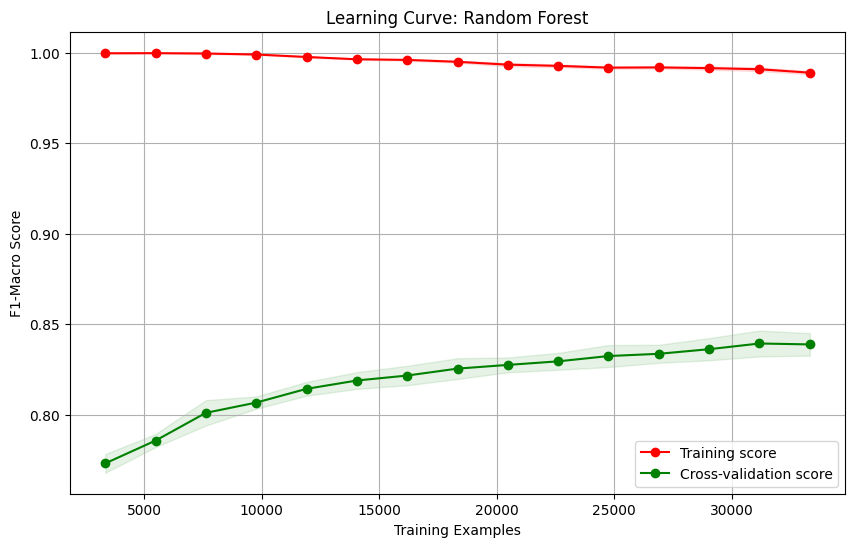

Generating learning curve for LogisticRegression...


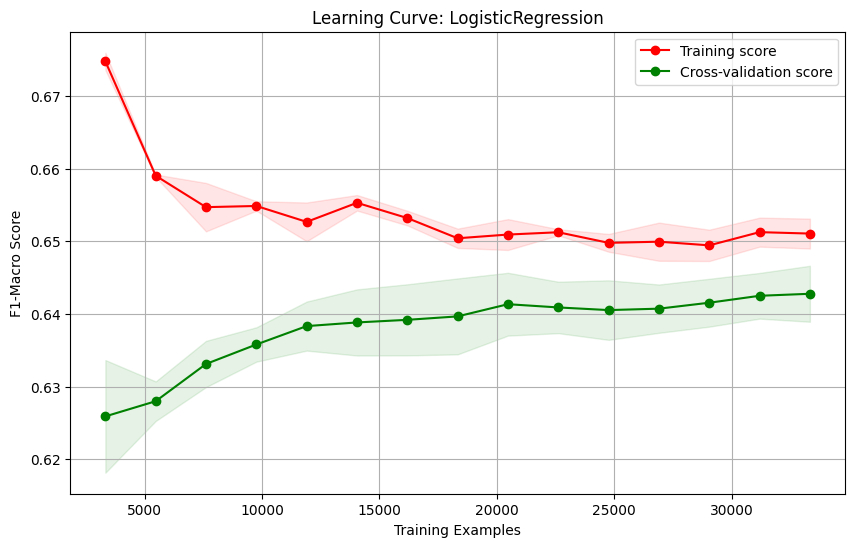

Generating learning curve for ExtraTreesClassifier...


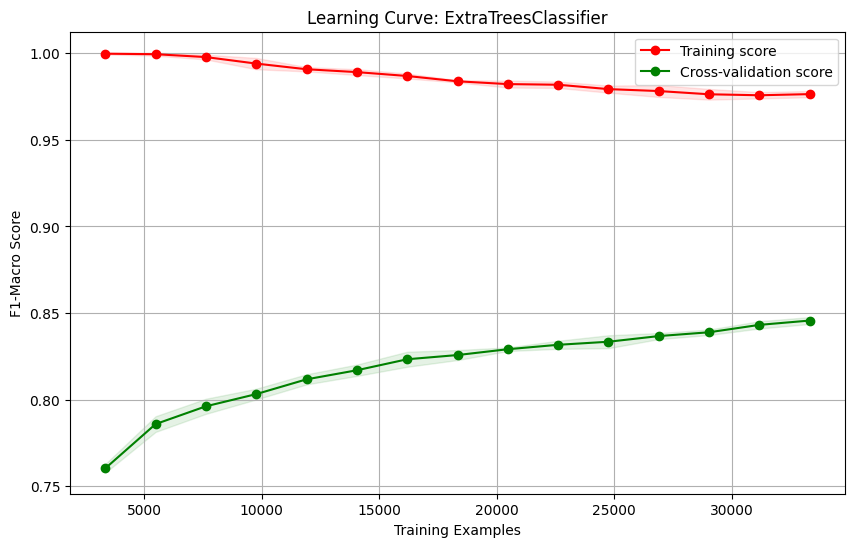

Generating learning curve for LinearSVC...


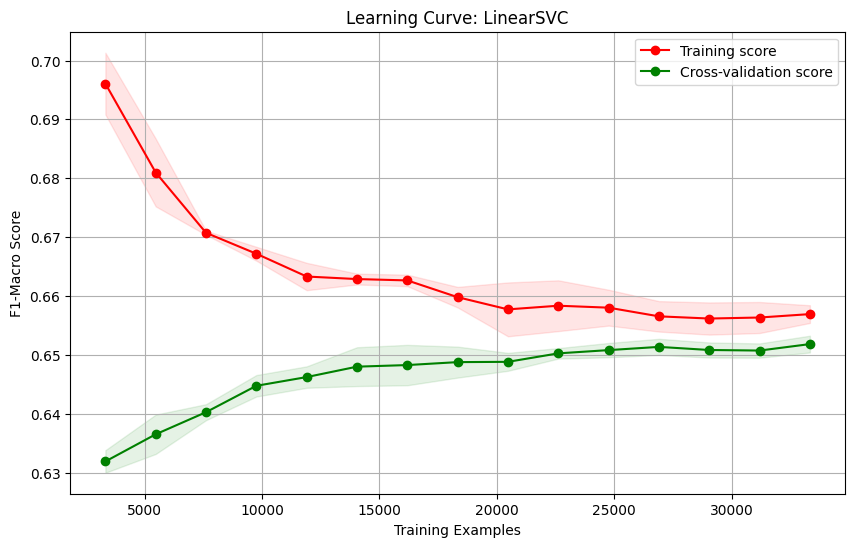

Generating learning curve for KNearestNeighbors...


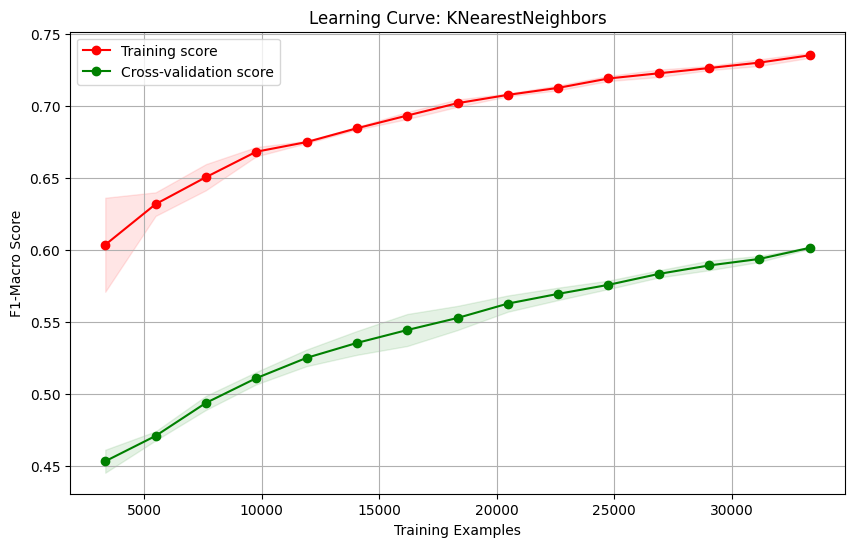

Generating learning curve for KernelSVM...


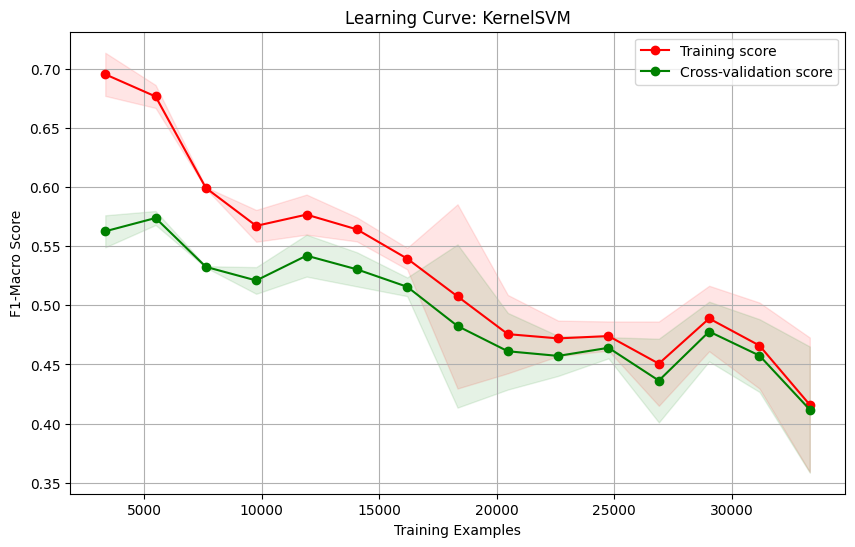

Generating learning curve for DecisionTree...


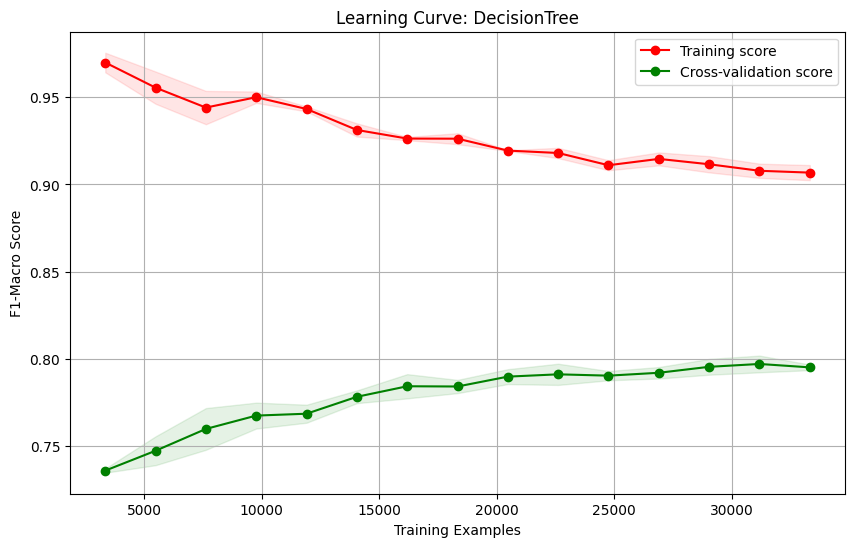

Generating learning curve for NaiveBayes...


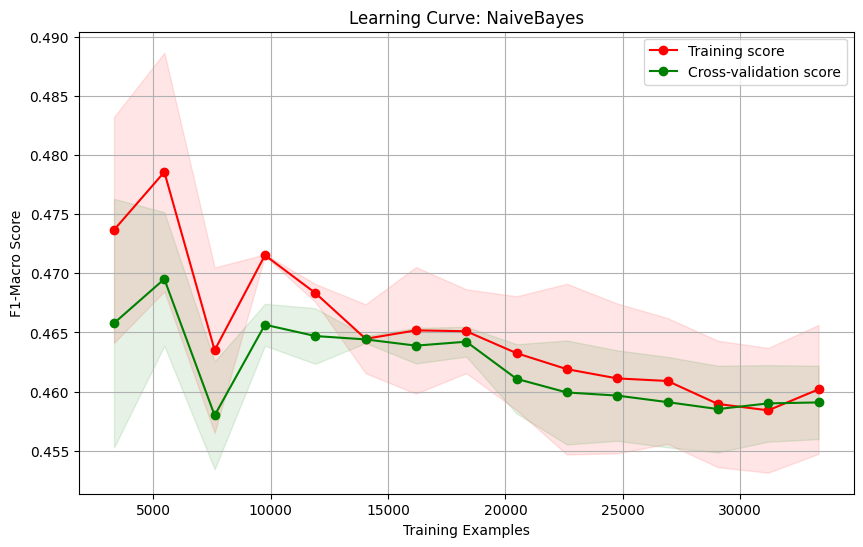

In [13]:
def plot_learning_curve(model, name, X : pd.DataFrame, y : pd.DataFrame):
    print(f"Generating learning curve for {name}...")
    
    sample_idx = np.random.choice(len(X), 50000, replace=False)
    x_diag = X.iloc[sample_idx]
    y_diag = y.ravel()[sample_idx]

    train_sizes, train_scores, test_scores = learning_curve(
        model, x_diag, y_diag, 
        train_sizes=np.linspace(0.1, 1.0, 15),
        cv=3, 
        scoring='f1_macro', 
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training Examples")
    plt.ylabel("F1-Macro Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(models["Random Forest"], "Random Forest", x_train, y_train)
plot_learning_curve(models["Logistic Regression"], "LogisticRegression", x_train, y_train)
plot_learning_curve(models["Extra Trees"], "ExtraTreesClassifier", x_train, y_train)
plot_learning_curve(models["Linear SVM"], "LinearSVC", x_train, y_train)
plot_learning_curve(models["K-Nearest Neighbors"], "KNearestNeighbors", x_train, y_train)
plot_learning_curve(models["Kernel SVM"], "KernelSVM", x_train, y_train)
plot_learning_curve(models["Decision Tree"], "DecisionTree", x_train, y_train)
plot_learning_curve(models["Naive Bayes"], "NaiveBayes", x_train, y_train)

**Nhận xét:** 
- Mô hình XGBoost có khả năng hội tụ tốt nhất.
- CatBoost và LightGBM có khả năng hội tụ tốt nhưng chậm hơn XGBoost.
- Mô hình K-Nearest Neighbors có khả năng hội tụ tốt và có độ ổn định cao.
- RandomForest, Extra Trees và Decision Tree có nguy cơ bị học quá khớp.
- Logistic Regression, LinearSVM đã đạt tới giới hạn về khả năng hội tụ.
- Naive Bayes và KernelSVM hầu như không hội tụ với dữ liệu huấn luyện.

### 3.6. Biểu đồ Feature Importance
Liệt kê 20 đặc trưng quan trọng nhất trong các mô hình XGBoost, CatBoost, LightGBM, Random Forest, Extra Tree và Decision Tree.

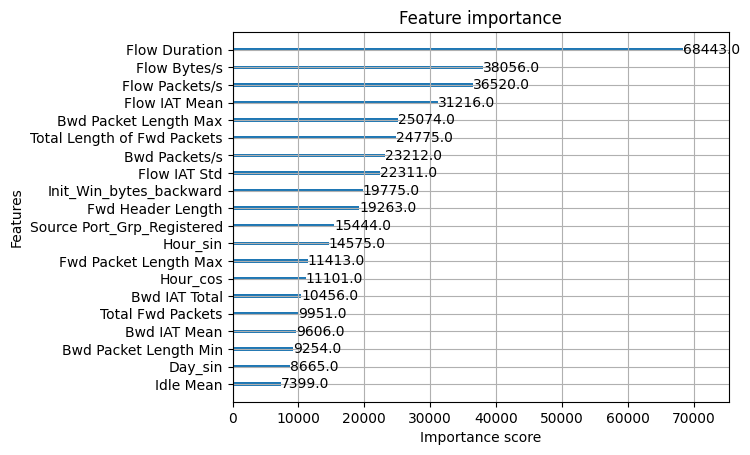

In [55]:
plot_importance(models["XGBoost"], max_num_features=20)
plt.show()

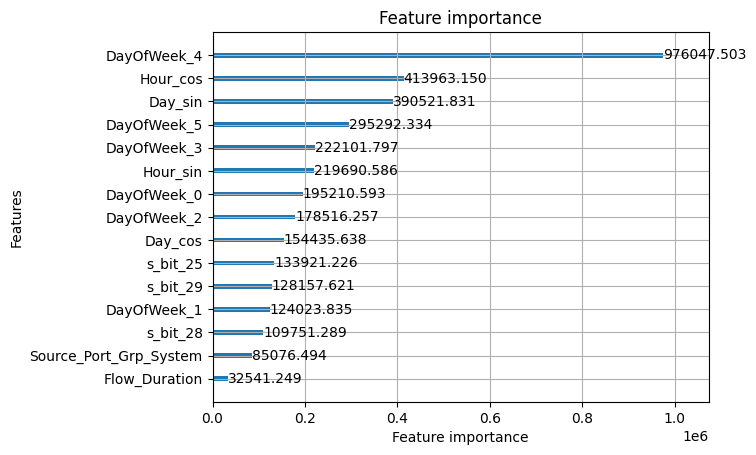

In [48]:
lgb.plot_importance(models["LightGBM"], max_num_features=15, importance_type='gain')
plt.show()

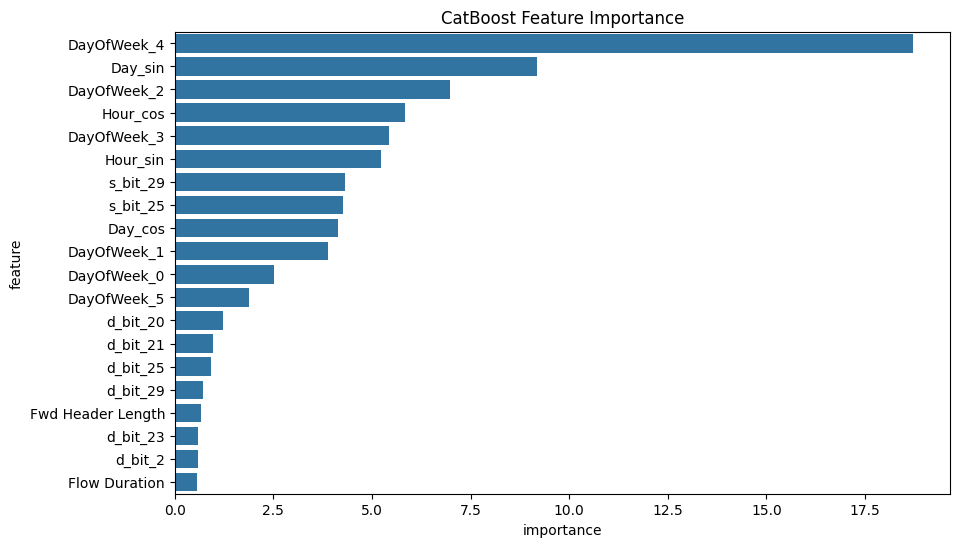

In [ ]:
feature_importance = models["CatBoost"].get_feature_importance()
feature_names = x_train_res.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('CatBoost Feature Importance')
plt.show()

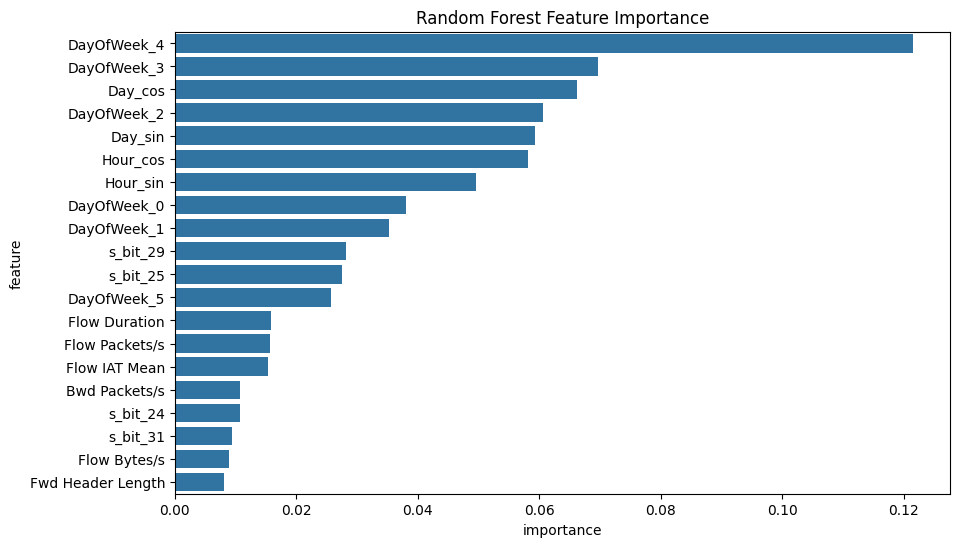

In [58]:
importances = models["Random Forest"].feature_importances_
feature_df = pd.DataFrame({
    'feature': x_train_res.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_df)
plt.title('Random Forest Feature Importance')
plt.show()


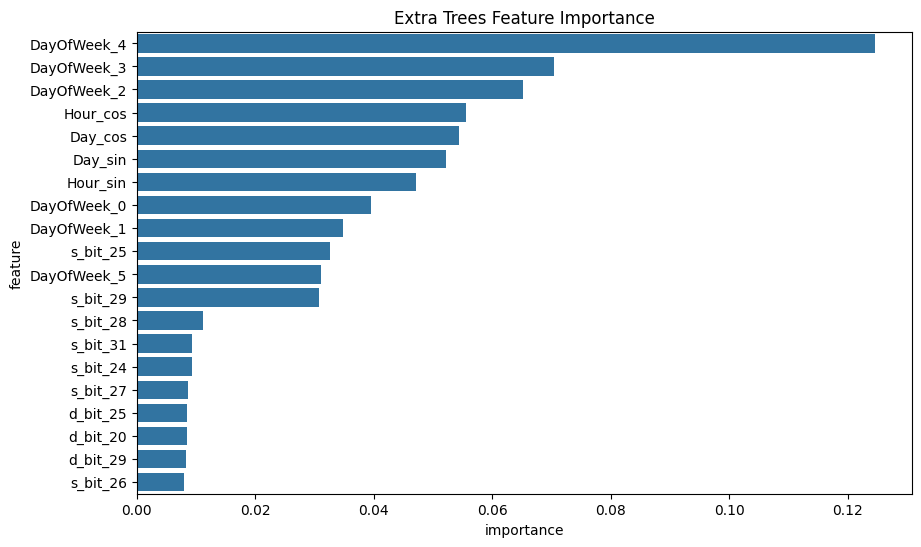

In [59]:
importances = models["Extra Trees"].feature_importances_
feature_df = pd.DataFrame({
    'feature': x_train_res.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_df)
plt.title('Extra Trees Feature Importance')
plt.show()


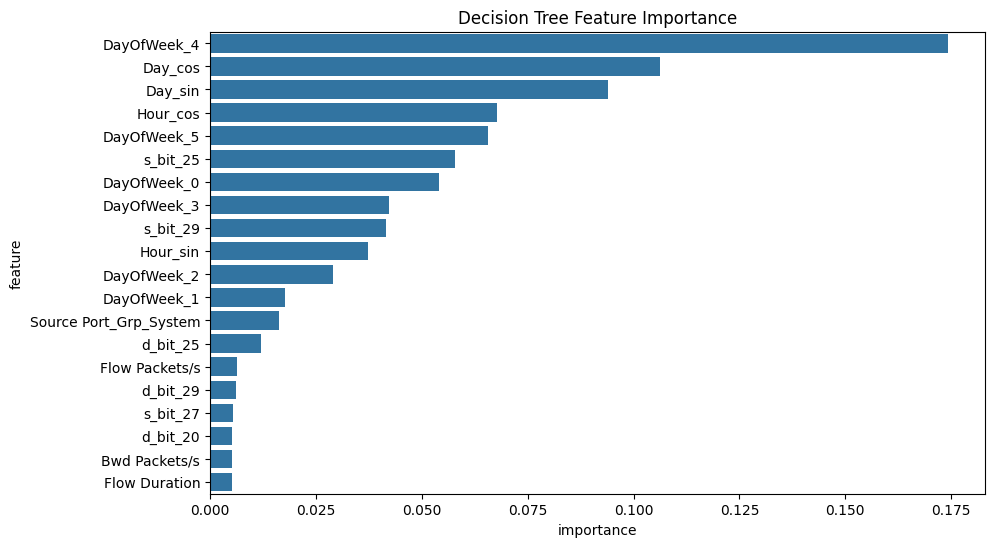

In [61]:
importances = models["Decision Tree"].feature_importances_
feature_df = pd.DataFrame({
    'feature': x_train_res.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_df)
plt.title('Decision Tree Feature Importance')
plt.show()


**Nhận xét:** Các đặc trưng về thời gian (DayOfWeek, Day) là quan trọng nhất với tất cả mô hình trừ XGBoost. Bit 25 và 29 cũng không kém phần quan trọng với hầu hết các mô hình.

### 3.6. Huấn luyện trên các mô hình tốt nhất với các tham số tối ưu
Các mô hình K-Nearest Neighbors, Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, DecisionTree được chọn làm các mô hình tốt nhất để tối ưu, đồng thời tạo thêm Stacking Model (với Random Forest, Extra Trees, XGBoost, LightGBM và CatBoost) để đánh giá hiệu suất của mô hình ensemble.

In [15]:
tuned_models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, weights="distance", metric="manhattan", n_jobs=-1),
    "Random Forest": RandomForestClassifier(class_weight='balanced', 
                                            n_jobs=-1, 
                                            n_estimators=100,
                                            random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', 
                                        n_jobs=-1, 
                                        n_estimators=100,
                                        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200,
                             max_depth=20,
                             learning_rate=0.05,
                             subsample=1.0,
                             max_delta_step=5,
                             reg_lambda=10,
                             random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(class_weight='balanced', 
                               n_estimators=2500,
                               num_leaves=128,
                               learning_rate=0.1,
                               n_jobs=-1, 
                               random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', 
                                   verbose=False, 
                                   iterations=2500,
                                   learning_rate=0.1,
                                   depth=6,
                                   random_state=RANDOM_STATE),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', 
        random_state=RANDOM_STATE
    ),
}

stacking_model = StackingClassifier(
    estimators=[
        ("rf", tuned_models["Random Forest"]),
        ("et", tuned_models["Extra Trees"]),
        ("xgb", tuned_models["XGBoost"]),
        ("lgbm", tuned_models["LightGBM"]),
        ("cb", tuned_models["CatBoost"]),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=3,
    n_jobs=2,
    passthrough=True
)

tuned_models["Stacking"] = stacking_model

In [16]:
for name, model in tuned_models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    model.fit(x_train_res, y_train_res)
    
    training_time = time.time() - start_time

    y_probs = model.predict_proba(x_val)
    threshold = 0.6
    y_pred_custom = []

    for prob in y_probs:
        if prob[3] > threshold:
            y_pred_custom.append(3)
        else:
            y_pred_custom.append(np.argmax(prob))

    f1 = f1_score(y_val, y_pred_custom, average='macro')
    acc = accuracy_score(y_val, y_pred_custom)
    
    print(f"Completed {name} in {training_time:.2f}s | F1: {f1:.4f} | Acc: {acc:.4f}\n")
    print(classification_report(y_val, y_pred_custom))

Training K-Nearest Neighbors...
Completed K-Nearest Neighbors in 0.47s | F1: 0.8126 | Acc: 0.8320

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     14744
           1       0.81      0.78      0.79     11708
           2       0.74      0.77      0.75      6740
           3       0.80      0.80      0.80      2371

    accuracy                           0.83     35563
   macro avg       0.81      0.81      0.81     35563
weighted avg       0.83      0.83      0.83     35563

Training Random Forest...
Completed Random Forest in 33.17s | F1: 0.8879 | Acc: 0.8944

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     14744
           1       0.86      0.86      0.86     11708
           2       0.82      0.82      0.82      6740
           3       0.92      0.92      0.92      2371

    accuracy                           0.89     35563
   macro avg       0.89      0.89      0.89     3556

**Nhận xét:** Mô hình Stacking Model có thời gian huấn luyện lâu nhất nhưng cũng có Accuracy và F1-Score cao nhất, tuy nhiên nó không tăng cao hơn đáng kể so với XGBoost hay LightGBM.

### 3.7. Plot biểu đồ AUC-ROC Curve để đánh giá khả năng phân lớp của các mô hình

Plotting ROC for K-Nearest Neighbors...


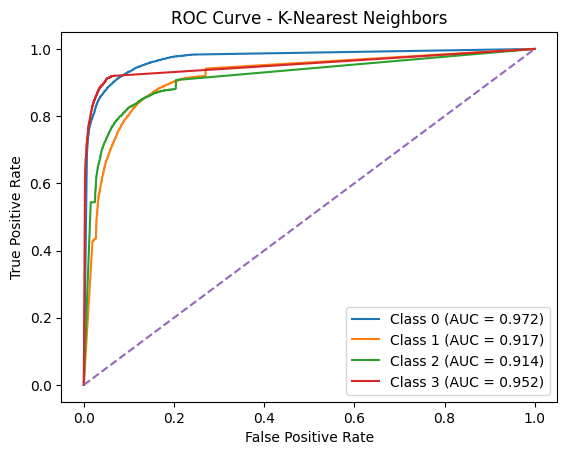

Plotting ROC for Random Forest...


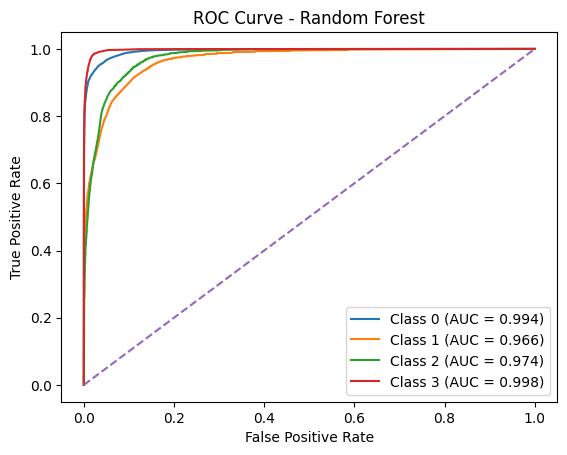

Plotting ROC for Extra Trees...


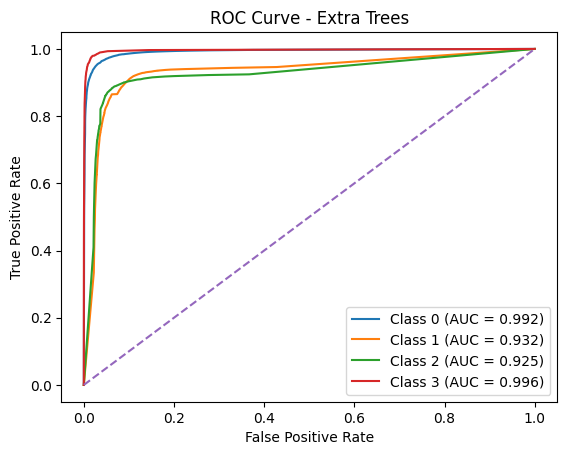

Plotting ROC for XGBoost...


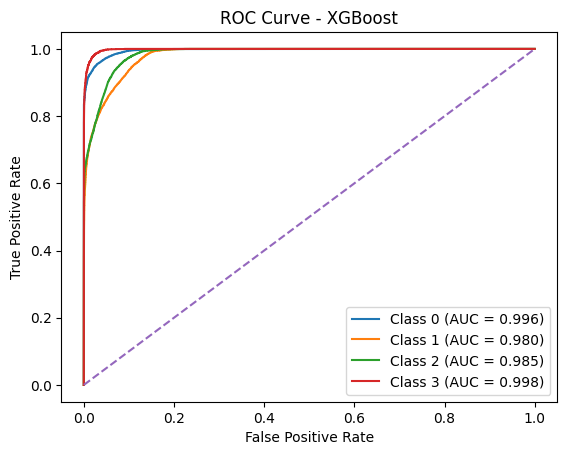

Plotting ROC for LightGBM...


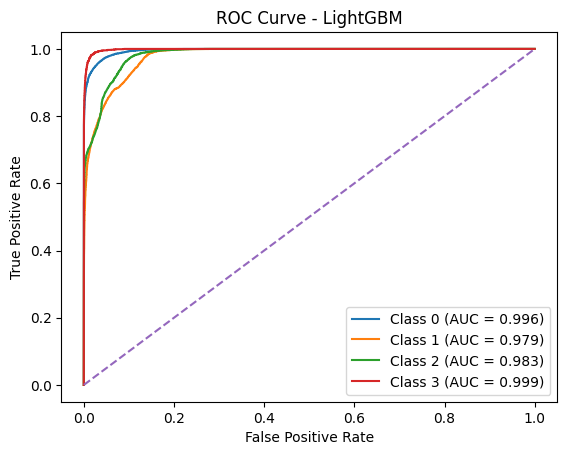

Plotting ROC for CatBoost...


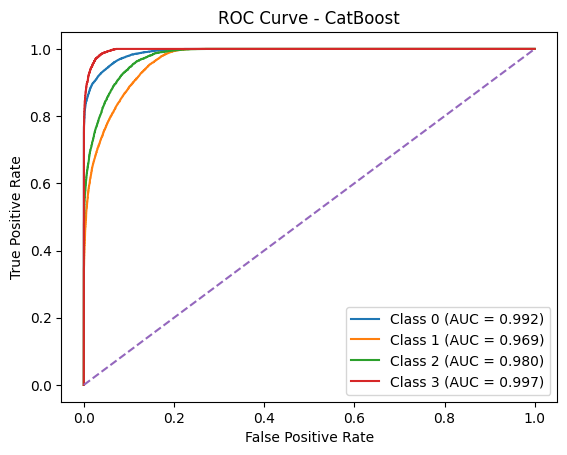

Plotting ROC for Decision Tree...


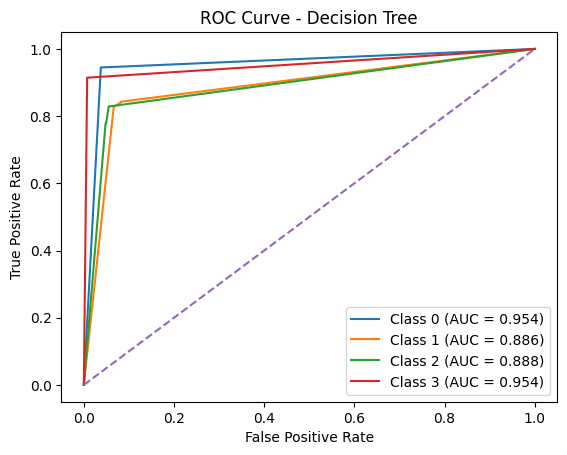

Plotting ROC for Stacking...


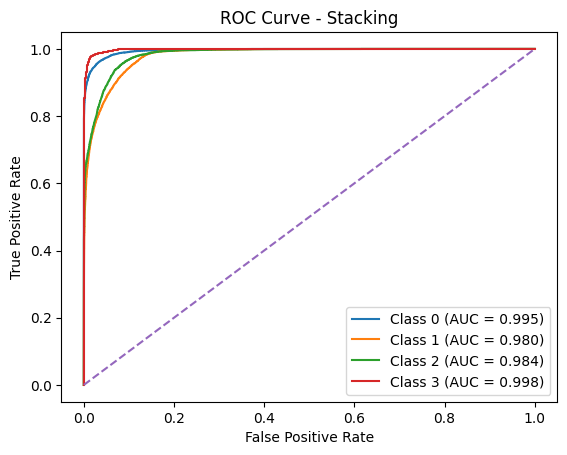

In [45]:
classes=[0, 1, 2, 3]
y_val_bin = label_binarize(y_val, classes=classes)

for name, model in tuned_models.items():
    print(f"Plotting ROC for {name}...")
    
    y_probs = model.predict_proba(x_val)
    
    plt.figure()
    
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")
    
    plt.plot([0, 1], [0, 1], linestyle="--")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    
    plt.show()

plt.show()

**Nhận xét:** Hầu hết các mô hình có khả năng phân lớp tốt với AUC Score ở hầu hết mô hình trên 0.9.

### 3.8. Lưu mô hình tốt nhất
Dùng joblib để lưu lại mô hình thành file để dùng cho tập test.

In [26]:
joblib.dump(tuned_models["XGBoost"], "../train/xgboost.joblib")

['../train/xgboost.joblib']

In [25]:
joblib.dump(tuned_models["Stacking"], "../train/stacking_model.joblib")

['../train/stacking_model.joblib']

# **Kết thúc**